# Diabetic Retinopathy Severity Classification (APTOS 2019) — Basic Baseline

**Goal:** Predict the diabetic-retinopathy severity grade of a retina fundus image on the **APTOS 2019** scale:

| diagnosis | meaning |
|---|---|
| 0 | No DR |
| 1 | Mild |
| 2 | Moderate |
| 3 | Severe |
| 4 | Proliferative DR |

**Data:** `train.csv` maps `id_code` → `diagnosis`. The images are PNGs named `<id_code>.png` inside `train_images/`. There is **no separate test set provided**, so we carve a **balanced held-out test split** out of the training data ourselves.

This is the **basic version**. The aim is an honest baseline:

1. Load labels from the CSV and build image paths.
2. Hold out a **class-balanced test set**, then split the rest into train/validation.
3. Train **two** models (ResNet18 + ResNet34) on one GPU.
4. Compare them on the held-out test set with confusion matrices.

The **advanced notebook** then improves on every weak point: it uses both T4 GPUs in parallel, trains 4 models, ensembles them, handles class imbalance, and adds Grad-CAM.

## 1. Imports & setup

In [ ]:
import os, time, copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns

torch.manual_seed(42); np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
print("GPUs available:", torch.cuda.device_count())
# The basic notebook uses ONE GPU. The advanced notebook uses both T4s in parallel.

## 2. Locate the data & load the CSV

In [6]:
DATA_ROOT = Path("/kaggle/input/aptos2019-blindness-detection")
if not DATA_ROOT.exists():
    DATA_ROOT = Path("/kaggle/input/competitions/aptos2019-blindness-detection")

CSV_PATH    = DATA_ROOT / "train.csv"
IMAGES_DIR  = DATA_ROOT / "train_images"

print("Data root:", DATA_ROOT, "| exists:", DATA_ROOT.exists())
print("CSV:", CSV_PATH, "| exists:", CSV_PATH.exists())
print("Images:", IMAGES_DIR, "| exists:", IMAGES_DIR.exists())

df = pd.read_csv(CSV_PATH)
print("\nCSV shape:", df.shape)
df.head()

Data root: /kaggle/input/competitions/aptos2019-blindness-detection | exists: True
CSV: /kaggle/input/competitions/aptos2019-blindness-detection/train.csv | exists: True
Images: /kaggle/input/competitions/aptos2019-blindness-detection/train_images | exists: True

CSV shape: (3662, 2)


,id_code,diagnosis
0,000c1434d8d7,2
1,001639a390f0,4
2,0024cdab0c1e,1
3,002c21358ce6,0
4,005b95c28852,0


In [7]:
# Class names for the 5 diagnosis grades
CLASSES = ["No_DR", "Mild", "Moderate", "Severe", "Proliferative_DR"]

# Build full image paths from id_code. APTOS images are .png
df["path"] = df["id_code"].apply(lambda x: str(IMAGES_DIR / f"{x}.png"))
df["label"] = df["diagnosis"].astype(int)

# Sanity check: do the files actually exist?
exists = df["path"].apply(os.path.exists)
print(f"Images found: {exists.sum()} / {len(df)}")
if exists.sum() < len(df):
    # try other extensions just in case
    def resolve(idc):
        for ext in (".png", ".jpg", ".jpeg"):
            p = IMAGES_DIR / f"{idc}{ext}"
            if p.exists(): return str(p)
        return None
    df["path"] = df["id_code"].apply(resolve)
    df = df[df["path"].notna()].reset_index(drop=True)
    print("After resolving extensions:", len(df), "images")

df[["id_code", "diagnosis", "label"]].head()

Images found: 3662 / 3662


,id_code,diagnosis,label
0,000c1434d8d7,2,2
1,001639a390f0,4,4
2,0024cdab0c1e,1,1
3,002c21358ce6,0,0
4,005b95c28852,0,0


## 3. Look at the class balance

APTOS 2019 is **heavily imbalanced** — most images are grade 0 (No DR), and grades 1/3/4 are comparatively rare. We just observe it here; the basic notebook doesn't correct for it (the advanced one does).

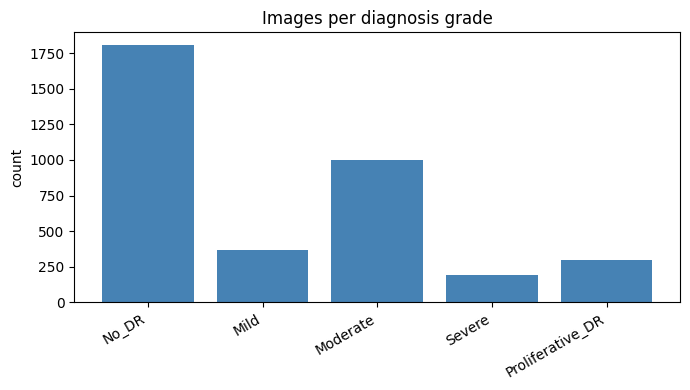

  0              No_DR: 1805
  1               Mild: 370
  2           Moderate: 999
  3             Severe: 193
  4   Proliferative_DR: 295


In [8]:
counts = df["label"].value_counts().sort_index()
plt.figure(figsize=(7,4))
plt.bar([CLASSES[i] for i in counts.index], counts.values, color="steelblue")
plt.title("Images per diagnosis grade")
plt.ylabel("count"); plt.xticks(rotation=30, ha="right")
plt.tight_layout(); plt.show()
for i, c in zip(counts.index, counts.values):
    print(f"  {i} {CLASSES[i]:>18}: {c}")

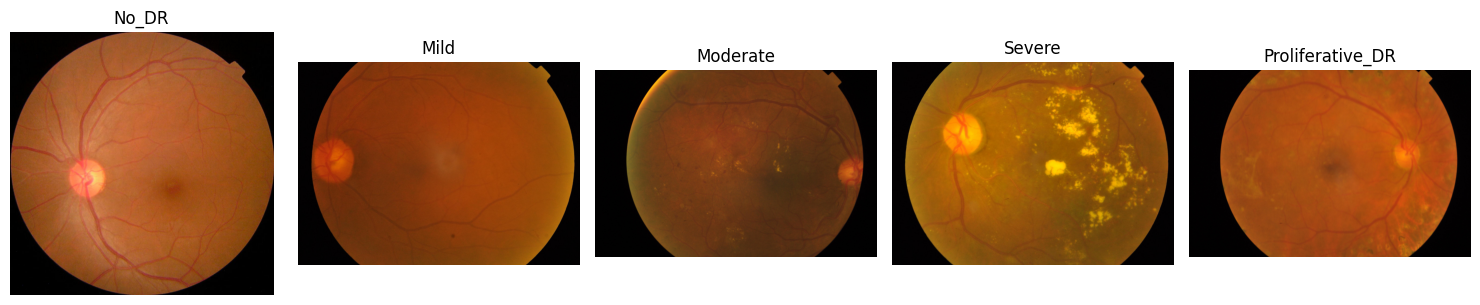

In [9]:
# Peek at one sample per class
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for ax, c in enumerate(range(5)):
    sub = df[df["label"] == c]
    if len(sub):
        img = Image.open(sub.iloc[0]["path"])
        ax_ = axes[c]; ax_.imshow(img); ax_.set_title(CLASSES[c]); ax_.axis("off")
plt.tight_layout(); plt.show()

## 4. Make a **balanced** held-out test set

You asked for this specifically: since there's no official test folder, we hold out part of the training data as a test set, and that test set must be **balanced across all 5 classes**.

Strategy:
- Decide how many images per class to reserve for testing. We take `TEST_PER_CLASS = min(class_count over all classes, cap)` so every class contributes the **same number** of test images.
- Pull exactly that many random images from each class into the **test** set.
- Everything left over becomes the **train+val** pool, which we then split 85/15 (stratified) for validation.

This makes the test accuracy honest: a model can't win just by predicting the majority class.

In [10]:
TEST_PER_CLASS = 50   # equal number of test images from EACH class

rng = np.random.RandomState(42)
test_parts, remaining_parts = [], []

min_class = df["label"].value_counts().min()
TEST_PER_CLASS = min(TEST_PER_CLASS, int(min_class * 0.5))  # don't drain a small class
print("Test images per class:", TEST_PER_CLASS)

for c in range(5):
    sub = df[df["label"] == c]
    take = sub.sample(n=TEST_PER_CLASS, random_state=42)
    test_parts.append(take)
    remaining_parts.append(sub.drop(take.index))

test_df = pd.concat(test_parts).sample(frac=1, random_state=42).reset_index(drop=True)
pool_df = pd.concat(remaining_parts).reset_index(drop=True)

print("\nBalanced TEST set:", len(test_df), "images")
print(test_df["label"].value_counts().sort_index().to_dict())
print("\nRemaining pool (train+val):", len(pool_df))

Test images per class: 50

Balanced TEST set: 250 images
{0: 50, 1: 50, 2: 50, 3: 50, 4: 50}

Remaining pool (train+val): 3412


In [11]:
# Split the remaining pool into train / validation (stratified)
train_df, val_df = train_test_split(
    pool_df, test_size=0.15, stratify=pool_df["label"], random_state=42
)
print("Train:", len(train_df), "| Val:", len(val_df), "| Test:", len(test_df))

Train: 2900 | Val: 512 | Test: 250


## 5. Dataset & transforms

Standard ImageNet normalization, resize to 224×224, light augmentation on the training set only.

In [ ]:
IMG_SIZE = 224
mean = [0.485, 0.456, 0.406]; std = [0.229, 0.224, 0.225]

# Fundus-safe augmentation: geometry is unconstrained, but keep color gentle
# (DR grading relies on subtle color cues — heavy hue/saturation jitter destroys signal)
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.10, contrast=0.10),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])
eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

class RetinaDataset(Dataset):
    def __init__(self, dataframe, transform):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, i):
        row = self.df.iloc[i]
        img = Image.open(row["path"]).convert("RGB")
        return self.transform(img), int(row["label"])

train_ds = RetinaDataset(train_df, train_tf)
val_ds   = RetinaDataset(val_df, eval_tf)
test_ds  = RetinaDataset(test_df, eval_tf)

BATCH_SIZE = 32
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
print("Batches -> train:", len(train_loader), " val:", len(val_loader), " test:", len(test_loader))

## 6. The model — EfficientNet-B0

We use **EfficientNet-B0** instead of the ResNets from the first attempt.
ResNet18/34 showed clear overfitting on APTOS 2019 (train_loss → 0.15 while val_loss stayed at 0.58).
EfficientNet-B0 avoids this because:
- Built-in **Dropout (0.2)** before the final classifier
- **Compound scaling** (balanced width / depth / resolution) → fewer redundant parameters
- **MBConv + Squeeze-and-Excitation** blocks → stronger feature selection per parameter

We further reduce overfitting with: label smoothing · weight decay · cosine LR schedule · early stopping.

In [ ]:
def build_model(num_classes=5):
    m = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
    m.classifier[1] = nn.Linear(m.classifier[1].in_features, num_classes)
    return m

MODEL_NAME = "efficientnet_b0"
print("Will train:", MODEL_NAME)

## 7. Training loop

A plain loop, trained once per model (sequentially, since this is the basic notebook on a single GPU).

In [ ]:
EPOCHS   = 25
PATIENCE = 6    # stop if val_acc doesn't improve for this many epochs

def run_epoch(model, loader, criterion, optimizer, train=True):
    model.train() if train else model.eval()
    total_loss, correct, n = 0.0, 0, 0
    with torch.set_grad_enabled(train):
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            if train: optimizer.zero_grad()
            out = model(imgs)
            loss = criterion(out, labels)
            if train:
                loss.backward(); optimizer.step()
            total_loss += loss.item() * imgs.size(0)
            correct += (out.argmax(1) == labels).sum().item()
            n += imgs.size(0)
    return total_loss / n, correct / n

def train_model():
    model = build_model().to(device)
    # label_smoothing penalises over-confident predictions → less overfitting
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    # weight_decay (L2) keeps weights small → less overfitting
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
    # cosine schedule slowly reduces LR → stable late convergence
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    hist = {"train_loss": [], "val_loss": [], "val_acc": []}
    best_acc, best_state, no_improve = 0.0, None, 0

    print(f"\n=== Training {MODEL_NAME} ===")
    for epoch in range(EPOCHS):
        t0 = time.time()
        tr_loss, tr_acc = run_epoch(model, train_loader, criterion, optimizer, train=True)
        va_loss, va_acc = run_epoch(model, val_loader,   criterion, optimizer, train=False)
        scheduler.step()
        hist["train_loss"].append(tr_loss)
        hist["val_loss"].append(va_loss)
        hist["val_acc"].append(va_acc)
        flag = ""
        if va_acc > best_acc:
            best_acc   = va_acc
            best_state = copy.deepcopy(model.state_dict())
            no_improve = 0
            flag = "  *best*"
        else:
            no_improve += 1
        print(f"  epoch {epoch+1:2d}/{EPOCHS}  train_loss {tr_loss:.3f} acc {tr_acc:.3f} | "
              f"val_loss {va_loss:.3f} acc {va_acc:.3f}  ({time.time()-t0:.0f}s){flag}")
        if no_improve >= PATIENCE:
            print(f"  Early stop at epoch {epoch+1} (best val_acc {best_acc:.3f})")
            break

    model.load_state_dict(best_state)
    return model, hist

In [ ]:
model, history = train_model()

## 8. Training curves (both models)

In [ ]:
h = history
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(h["train_loss"], label="train"); ax[0].plot(h["val_loss"], label="val")
ax[0].set_title(f"Loss — {MODEL_NAME}"); ax[0].set_xlabel("epoch"); ax[0].legend()
ax[1].plot(h["val_acc"], label="val acc", color="green")
ax[1].set_title(f"Validation accuracy — {MODEL_NAME}"); ax[1].set_xlabel("epoch"); ax[1].legend()
plt.tight_layout(); plt.show()
print(f"Best val acc: {max(h['val_acc']):.4f}")

## 9. Evaluate on the balanced TEST set

Because the test set has equal images per class, accuracy here is a fair measure and the confusion matrix is easy to read.

In [ ]:
def evaluate(model):
    model.eval(); preds, labels_all = [], []
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs = imgs.to(device)
            preds.extend(model(imgs).argmax(1).cpu().numpy())
            labels_all.extend(labels.numpy())
    return np.array(labels_all), np.array(preds)

y_true, y_pred = evaluate(model)
acc = accuracy_score(y_true, y_pred)
print(f"\n########## {MODEL_NAME}  (balanced test accuracy = {acc:.3f}) ##########")
print(classification_report(y_true, y_pred, target_names=CLASSES, zero_division=0))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title(f"Confusion Matrix — {MODEL_NAME}")
plt.tight_layout(); plt.show()

## 10. Save the models

In [ ]:
torch.save(model.state_dict(), f"{MODEL_NAME}_data2.pth")
print(f"Saved: {MODEL_NAME}_data2.pth")
print("Copy this file into the models/ folder of the Streamlit app.")